In [1]:
# installed mute to a specific directory,
# not necessary with default pip install
import sys
sys.path.append("../data/mute_imports")

# just loads matplotlib and numpy
from ag import *

from datetime import date

import mute.constants as mtc
import mute.underground as mtu
import mute.surface as mts
import mute.propagation as mtp
import scipy.interpolate as sciint

colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']

mtc.set_verbose(0)
mtc.set_output(True)
mtc.set_lab("Default")
mtc.set_overburden("flat")
mtc.set_vertical_depth(1.460)
mtc.set_medium("water")
mtc.set_density(1.03)
mtc.set_n_muon(100)
# n=1:    10min
# n=10:   20min

In [2]:
s_flux = mts.load_s_fluxes_from_file(
    primary_model = "GSF",
    interaction_model = "SIBYLL-2.3d",
    atmosphere = "MSIS00",
    location='USStd',
    month = None,
    force = False,
)
survival_probability_tensor = (
    mtp.load_survival_probability_tensor_from_file(force=False)
)
u_fluxes_from_convolution = mtu._do_convolution(
    s_flux, survival_probability_tensor)
u_flux = np.zeros((len(mtc.ENERGIES), len(mtc.angles)))
for i,E in enumerate(mtc.ENERGIES):
    gd, ga = np.meshgrid(mtc._SLANT_DEPTHS, mtc.ANGLES_FOR_S_FLUXES)
    ad, aa = np.meshgrid(mtc.slant_depths, mtc.angles)
    eflux = u_fluxes_from_convolution[:,i,:]
    u_intensities = np.nan_to_num(
        np.exp(sciint.griddata(
            (gd.flatten(), ga.flatten()),
            np.log(eflux.T.flatten()),
            (ad, aa),)))
    u_flux[i,:] = np.diagonal(u_intensities)

/tmp/ipykernel_9477/756504152.py:22: RuntimeWarning: divide by zero encountered in log
  np.log(eflux.T.flatten()),


In [3]:
def angle_spectrum(flux, angles, energies):
    angle_spectrum = nn.zeros(len(angles))
    for i in range(len(angles)):
        angle_spectrum[i] = integrate.simpson(flux[:,i], energies)
    return angle_spectrum
def energy_spectrum(flux, angles, energies):
    energy_spectrum = nn.zeros(len(energies))
    rad = nn.deg2rad(angles)
    for i in range(len(energies)):
        energy_spectrum[i] = integrate.simpson(flux[i,:] \
            *2*nn.pi*nn.sin(rad), rad)
    return energy_spectrum

In [4]:
def intensity_mei(h, theta):
    h = h * mtc.get_density()
    sec = 1 / nn.cos(theta)
    return (8.60e-6 * nn.exp(-h*sec/0.45) + 0.44e-6 * nn.exp(-h*sec/0.87)) * sec
def intensity_menon(h, theta):
    h = h * mtc.get_density()
    sec = 1 / nn.cos(theta)
    lam = 0.810
    i0 = 98e-7 * nn.exp(-h/lam)
    return i0 * sec * nn.exp(-h/lam*(sec-1))

total flux [1/cm2 s] 4.0084043229889915e-07


/tmp/ipykernel_9477/1934526888.py:26: RuntimeWarning: divide by zero encountered in log10
  nn.log10(flux.T * 1e3), rasterized=True)
/tmp/ipykernel_9477/1934526888.py:25: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pp.pcolor(*nn.meshgrid(energies/1e3, angles),
/tmp/ipykernel_9477/1934526888.py:27: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pp.colorbar(label="$\log_{10}$ flux [1/cm² s sr GeV]")


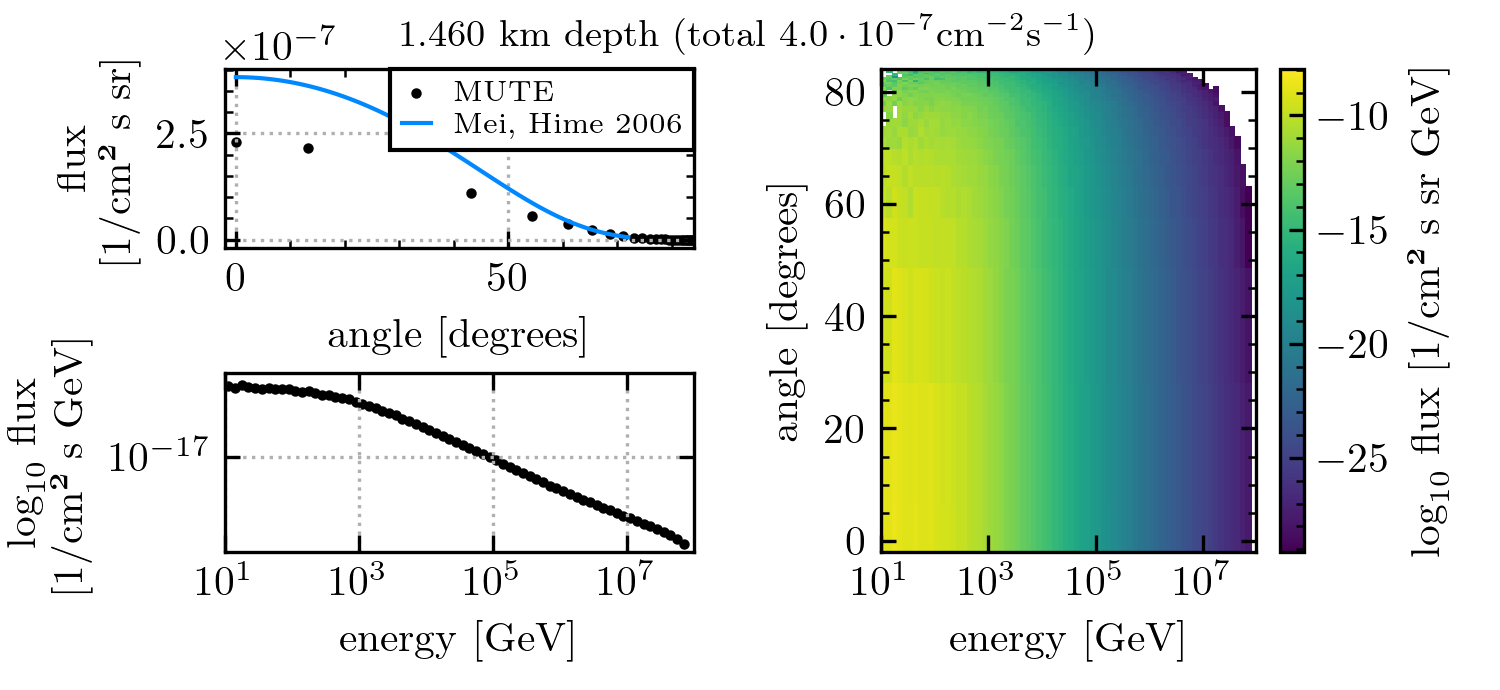

total flux [1/cm2 s] 0.013989637419498876


/tmp/ipykernel_9477/1934526888.py:25: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pp.pcolor(*nn.meshgrid(energies/1e3, angles),
/tmp/ipykernel_9477/1934526888.py:27: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pp.colorbar(label="$\log_{10}$ flux [1/cm² s sr GeV]")
/tmp/ipykernel_9477/1934526888.py:42: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  if nn.all(flux == u_flux):


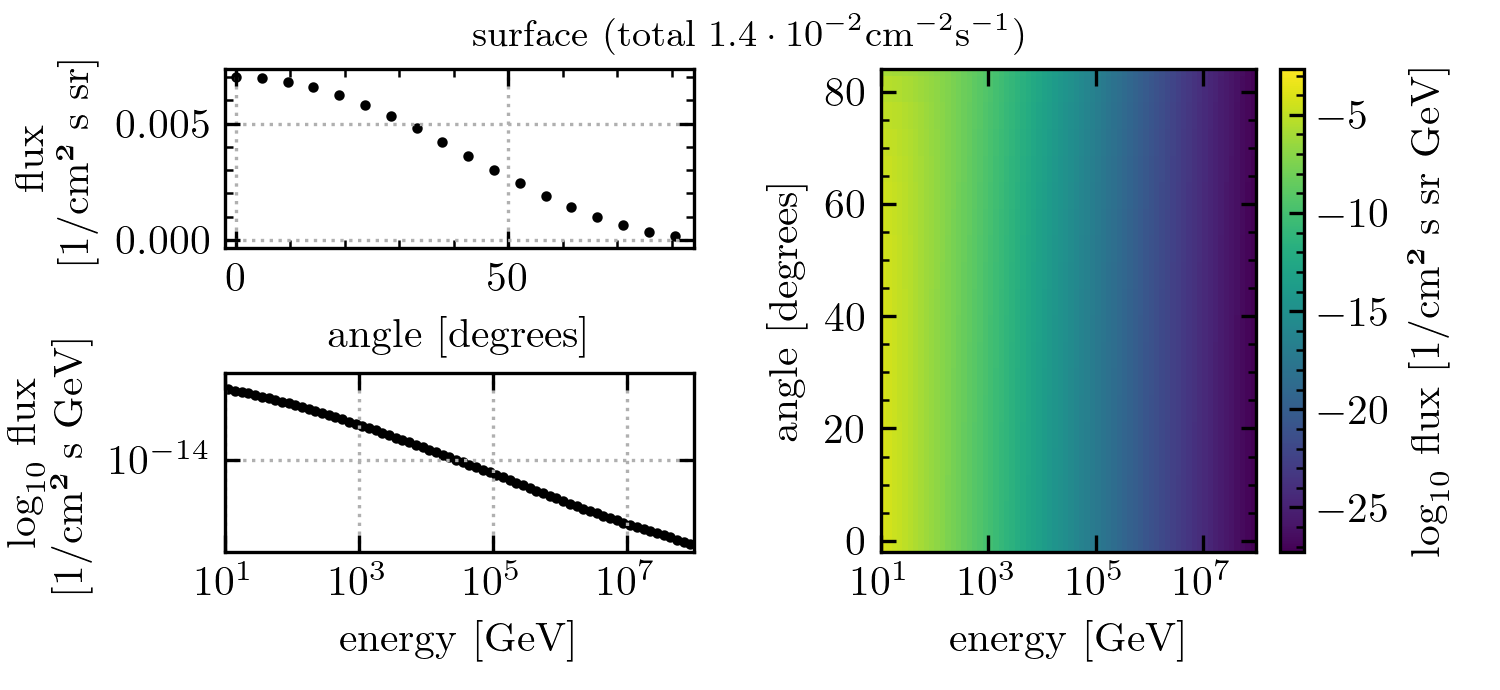

/tmp/ipykernel_9477/1934526888.py:89: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  if nn.all(flux == u_flux):


In [5]:
for title, flux, angles, energies, save in [
    ["%.3f km depth" % mtc.get_vertical_depth(), u_flux,
     mtc.angles, mtc.ENERGIES, 'underground'],
    ["surface", s_flux,
     mtc.ANGLES_FOR_S_FLUXES, mtc.ENERGIES, 'surface']
]:
    
    # these should all be the same for underground
    a =  angle_spectrum(flux, angles, energies)
    e = energy_spectrum(flux, angles, energies)
    int1 = integrate.simpson(a*2*nn.pi*nn.sin(nn.deg2rad(angles)), nn.deg2rad(angles))
    int2 = integrate.simpson(e, energies)
    assert nn.isclose(int1, int2)
    assert 0.9 < int1 / mtu.calc_u_tot_flux() < 1.1 \
        or 0.9 < int1 / mts.calc_s_tot_flux() < 1.1
    print('total flux [1/cm2 s]', int1)
    exp = nn.floor(nn.log10(int1))
    base = int1 / 10.**exp
    
    pp.figure(figsize=(5,2.3))
    pp.suptitle('%s (total $%.1f\cdot10^{%i}\mathrm{cm}^{-2}\mathrm{s}^{-1}$)' \
                % (title, base, exp), fontsize=9)
    
    pp.subplot(122)
    pp.pcolor(*nn.meshgrid(energies/1e3, angles),
        nn.log10(flux.T * 1e3), rasterized=True)
    pp.colorbar(label="$\log_{10}$ flux [1/cm² s sr GeV]")
    pp.xscale("log")
    pp.xlabel("energy [GeV]")
    pp.ylabel("angle [degrees]")
    pp.xticks(10**nn.arange(1,8,2))
    pp.xlim(1e1,1e8)
    pp.ylim(-2, max(mtc.angles))

    pp.subplot(221)
    pp.scatter(angles, angle_spectrum(flux, angles, energies),
        label='MUTE',
        color=colors[0],
        marker='.')
    pp.xlim(-2, max(mtc.angles))

    if nn.all(flux == u_flux):
        compare_to_native_integration = False
        if compare_to_native_integration:
            intensities = mtu.calc_u_intensities(
                method = 'sd',
                interaction_model = "SIBYLL-2.3d",
                primary_model = "GSF",
                atmosphere = "MSIS00")
            pp.scatter(mtc.angles, intensities, marker='o',
                color=colors[2])
        theta = nn.linspace(0, 0.4*nn.pi, 100)
        compare_to_mei = True
        if compare_to_mei:
            pp.plot(theta*180/nn.pi,
                intensity_mei(mtc.get_vertical_depth(), theta), 
                label="Mei, Hime 2006",
                color=colors[1])
        compare_to_menon = False
        if compare_to_menon:
            pp.plot(theta*180/nn.pi,
                intensity_menon(mtc.get_vertical_depth(), theta), 
                label="Menon et al. 1967",
                color=colors[3])
        pp.legend(loc='upper right', borderaxespad=0, fontsize=7)
    pp.ylabel("flux\n[1/cm² s sr]")
    pp.xlabel("angle [degrees]")

    pp.subplot(223)
    pp.scatter(
        energies / 1e3,
        #nn.log10(energy_spectrum(flux, angles, energies) * 1e3 * (energies / 1e3)**3),
        energy_spectrum(flux, angles, energies) * 1e3,
        marker='.')
    pp.ylabel("$\log_{10}$ flux\n[1/cm² s GeV]")
    pp.yscale('log')
    #pp.ylim(1e-5, 1)
    pp.xlabel("energy [GeV]")
    pp.xscale('log')
    pp.xticks(10**nn.arange(1,8,2))
    pp.xlim(1e1,1e8)
    
    pp.subplots_adjust(wspace=0.4, left=0.15, bottom=0.2, right=.9, hspace=0.7)
    pp.savefig('plot_%s.pdf' % save)
    pp.show()

    with open("fluxtable_%s.csv" % save, "w") as f:
        print("# %s, ag" % date.today(), file=f)
        if nn.all(flux == u_flux):
            print("# %.3f km depth" % mtc.get_vertical_depth(), file=f)
        elif nn.all(flux == s_flux):
            print("# surface", file=f)
        else: raise
        print("# run with n=%i muons per angle and energy" % mtc.get_n_muon(), file=f)
        print("# first row: angles [degrees]", file=f)
        print("# first column: energies [MeV]", file=f)
        print("# other entries: flux [1 / cm² s sr MeV]", file=f)

        print("EMPTY      ", end=" ", file=f)
        for a in angles:
            print("%+.4e" % a, end=" ", file=f)
        print(file=f)
        for i, row in enumerate(flux):
            print("%+.4e" % energies[i], end=" ", file=f)
            for r in row:
                print("%+.4e" % r, end=" ", file=f)
            print(file=f)
    pd.read_csv("fluxtable_%s.csv" % save, comment='#', header=None, delim_whitespace=True);